In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import sys
print(sys.executable)
print(sys.version)

os.chdir(os.path.expanduser("~/DLNLP-ALBERT"))
print("Now in:", os.getcwd())
!ls

SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)
print("src on path:", SRC, "| exists:", os.path.isdir(SRC))

import torch, transformers, pandas as pd
from transformers import AlbertConfig, AlbertModel
print("transformers:", transformers.__version__, "| CUDA:", torch.cuda.is_available())

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    embed = sum(p.numel() for n, p in model.named_parameters() if "embedding" in n.lower())
    return total, embed

std_cfg = AlbertConfig(vocab_size=30000, hidden_size=768, embedding_size=768,
                       num_hidden_layers=12, num_attention_heads=12)
fac_cfg = AlbertConfig(vocab_size=30000, hidden_size=768, embedding_size=128,
                       num_hidden_layers=12, num_attention_heads=12)

for name, cfg in [("standard", std_cfg), ("factorized", fac_cfg)]:
    total, embed = count_params(AlbertModel(cfg))
    print(f"{name:10s} | total={total:,} | embedding={embed:,}")

%run experiments/factorized_embeddings/run_factorized_embeddings.py





/opt/micromamba/bin/python
3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:48:23) [GCC 13.3.0]
Now in: /home/jovyan/DLNLP-ALBERT
README.md  docs		outputs		 plots		   results  src
configs    experiments	outputs.gitkeep  requirements.txt  scripts
src on path: /home/jovyan/DLNLP-ALBERT/src | exists: True
transformers: 4.56.2 | CUDA: True
standard   | total=52,165,888 | embedding=24,026,880
factorized | total=32,144,128 | embedding=4,005,120

=== Embedding ablation config: configs/factorized_embeddings/standard_embeddings.yaml ===
{'experiment_name': 'factorized_embeddings', 'configuration': 'standard_embeddings', 'model_label': 'ALBERT-standard-embeddings', 'model_name': 'from_config', 'model_source': 'from_config', 'task_name': 'sst2', 'parameters': 31706882, 'embedding_parameters': 23436288, 'notes': 'Randomly initialized controlled architecture; not a pretrained checkpoint.'}

=== Embedding ablation config: configs/factorized_embeddings/factorized_embeddings.yaml ===
{'exper

In [2]:
import pandas as pd
df = pd.read_csv("results/embedding_results.csv")
df

,experiment_name,configuration,model_label,model_name,model_source,task_name,parameters,embedding_parameters,notes
0,factorized_embeddings,standard_embeddings,ALBERT-standard-embeddings,from_config,from_config,sst2,31706882,23436288,Randomly initialized controlled architecture; ...
1,factorized_embeddings,factorized_embeddings,ALBERT-factorized-embeddings,from_config,from_config,sst2,11685122,3906048,Randomly initialized controlled architecture; ...
2,factorized_embeddings,standard_embeddings,ALBERT-standard-embeddings,from_config,from_config,sst2,31706882,23436288,Randomly initialized controlled architecture; ...
3,factorized_embeddings,factorized_embeddings,ALBERT-factorized-embeddings,from_config,from_config,sst2,11685122,3906048,Randomly initialized controlled architecture; ...


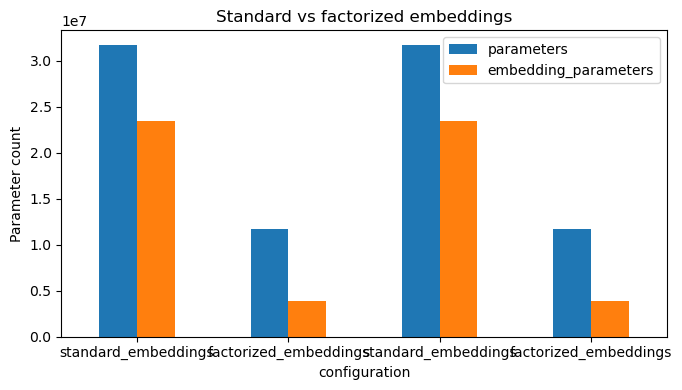

In [3]:
import matplotlib.pyplot as plt

ax = df.plot(x="configuration", y=["parameters", "embedding_parameters"],
             kind="bar", figsize=(7,4))
ax.set_ylabel("Parameter count")
ax.set_title("Standard vs factorized embeddings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
print(open("configs/factorized_embeddings/standard_embeddings.yaml").read())
print("---")
print(open("configs/factorized_embeddings/factorized_embeddings.yaml").read())

experiment_name: factorized_embeddings
configuration: standard_embeddings
model_source: from_config
architecture: albert
tokenizer_name: albert-base-v2
model_label: ALBERT-standard-embeddings
task_name: sst2
sharing_strategy: full_sharing
max_length: 128
epochs: 3
batch_size: 16
learning_rate: 2.0e-5
seed: 42
save_model: false
model_config:
  embedding_size: 768
  hidden_size: 768
  num_hidden_layers: 12
  num_attention_heads: 12
  intermediate_size: 3072

---
experiment_name: factorized_embeddings
configuration: factorized_embeddings
model_source: from_config
architecture: albert
tokenizer_name: albert-base-v2
model_label: ALBERT-factorized-embeddings
task_name: sst2
sharing_strategy: full_sharing
max_length: 128
epochs: 3
batch_size: 16
learning_rate: 2.0e-5
seed: 42
save_model: false
model_config:
  embedding_size: 128
  hidden_size: 768
  num_hidden_layers: 12
  num_attention_heads: 12
  intermediate_size: 3072



In [5]:
import unicodedate


ModuleNotFoundError: No module named 'unicodedate'

In [ ]:
import yaml, pandas as pd

def flatten(cfg):
    flat = {}
    for k, v in cfg.items():
        if isinstance(v, dict):
            for subk, subv in v.items():
                flat[subk] = subv
        else:
            flat[k] = v
    return flat

files = ["standard_embeddings.yaml", "factorized_embeddings.yaml"]
rows = {}
for f in files:
    cfg = yaml.safe_load(open("configs/factorized_embeddings/" + f))
    rows[cfg["configuration"]] = flatten(cfg)

compare = pd.DataFrame(rows)
compare

In [ ]:
diff = compare[compare.iloc[:, 0] != compare.iloc[:, 1]]
print("Fields that differ between the two configs taken from the table above:")
diff

In [ ]:
V = 30000      # vocab size (albert-base-v2)
H = 768        # hidden size
E_std = 768    # standard embedding size
E_fac = 128    # factorized embedding size

std = V * E_std                  # one big V x H table
fac = V * E_fac + E_fac * H      # two matrices: V x E + E x H
print("Title:Factorized embeddings reduce parameters ~6× — the arithmetic \n")
print(f"Standard   embedding matrix: V*H        = {V}*{E_std}            = {std:,}")
print(f"Factorized embedding matrix: V*E + E*H  = {V}*{E_fac} + {E_fac}*{H} = {fac:,}")
print(f"Reduction factor: {std/fac:.1f}x")

In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import sys
os.chdir(os.path.expanduser("~/DLNLP-ALBERT"))

SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import torch
print("In:", os.getcwd())
print("CUDA available:", torch.cuda.is_available())

In [ ]:
%run experiments/factorized_embeddings/run_factorized_embeddings.py --train

In [ ]:
%pip install "accelerate>=0.26.0"

In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import sys
os.chdir(os.path.expanduser("~/DLNLP-ALBERT"))

SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import torch
print("In:", os.getcwd())
print("CUDA available:", torch.cuda.is_available())

In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import sys
os.chdir(os.path.expanduser("~/DLNLP-ALBERT"))

SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import torch
print("In:", os.getcwd())
print("CUDA available:", torch.cuda.is_available())

In [ ]:
%run experiments/factorized_embeddings/run_factorized_embeddings.py --train

In [6]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import sys
os.chdir(os.path.expanduser("~/DLNLP-ALBERT"))

SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import torch
print("In:", os.getcwd())
print("CUDA available:", torch.cuda.is_available())

In: /home/jovyan/DLNLP-ALBERT
CUDA available: True


In [7]:
%run experiments/factorized_embeddings/run_factorized_embeddings.py --train


=== Embedding ablation config: configs/factorized_embeddings/standard_embeddings.yaml ===


/home/jovyan/DLNLP-ALBERT/src/albert_project/training.py:101: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.327300,0.540180,0.769495
2,0.283800,0.504363,0.803899
3,0.243400,0.517205,0.824541


{'experiment_name': 'factorized_embeddings', 'configuration': 'standard_embeddings', 'model_label': 'ALBERT-standard-embeddings', 'model_name': 'from_config', 'model_source': 'from_config', 'task_name': 'sst2', 'train_fraction': 1.0, 'seed': 42, 'epochs': 3.0, 'batch_size': 16, 'learning_rate': 2e-05, 'max_length': 128, 'train_examples': 67349, 'validation_examples': 872, 'parameters': 31706882, 'embedding_parameters': 23436288, 'training_time_seconds': 4503.441, 'gpu_memory_mb': 2496.9, 'notes': 'Randomly initialized controlled architecture; not a pretrained checkpoint.', 'loss': 0.517204999923706, 'accuracy': 0.8245412844036697, 'runtime': 7.1962, 'samples_per_second': 121.175, 'steps_per_second': 7.643, 'epoch': 3.0}

=== Embedding ablation config: configs/factorized_embeddings/factorized_embeddings.yaml ===


/home/jovyan/DLNLP-ALBERT/src/albert_project/training.py:101: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.422300,0.457815,0.786697
2,0.325500,0.489773,0.802752
3,0.277800,0.461503,0.813073


{'experiment_name': 'factorized_embeddings', 'configuration': 'factorized_embeddings', 'model_label': 'ALBERT-factorized-embeddings', 'model_name': 'from_config', 'model_source': 'from_config', 'task_name': 'sst2', 'train_fraction': 1.0, 'seed': 42, 'epochs': 3.0, 'batch_size': 16, 'learning_rate': 2e-05, 'max_length': 128, 'train_examples': 67349, 'validation_examples': 872, 'parameters': 11685122, 'embedding_parameters': 3906048, 'training_time_seconds': 4428.679, 'gpu_memory_mb': 2259.598, 'notes': 'Randomly initialized controlled architecture; not a pretrained checkpoint.', 'loss': 0.46150270104408264, 'accuracy': 0.8130733944954128, 'runtime': 7.1809, 'samples_per_second': 121.433, 'steps_per_second': 7.659, 'epoch': 3.0}


In [8]:
import pandas as pd
pd.read_csv("results/embedding_results.csv")

,experiment_name,configuration,model_label,model_name,model_source,task_name,parameters,embedding_parameters,notes,train_fraction,...,train_examples,validation_examples,training_time_seconds,gpu_memory_mb,loss,accuracy,runtime,samples_per_second,steps_per_second,epoch
0,factorized_embeddings,standard_embeddings,ALBERT-standard-embeddings,from_config,from_config,sst2,31706882,23436288,Randomly initialized controlled architecture; ...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,factorized_embeddings,factorized_embeddings,ALBERT-factorized-embeddings,from_config,from_config,sst2,11685122,3906048,Randomly initialized controlled architecture; ...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,factorized_embeddings,standard_embeddings,ALBERT-standard-embeddings,from_config,from_config,sst2,31706882,23436288,Randomly initialized controlled architecture; ...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,factorized_embeddings,factorized_embeddings,ALBERT-factorized-embeddings,from_config,from_config,sst2,11685122,3906048,Randomly initialized controlled architecture; ...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,factorized_embeddings,standard_embeddings,ALBERT-standard-embeddings,from_config,from_config,sst2,31706882,23436288,Randomly initialized controlled architecture; ...,1.0,...,67349.0,872.0,4503.441,2496.900,0.517205,0.824541,7.1962,121.175,7.643,3.0
5,factorized_embeddings,factorized_embeddings,ALBERT-factorized-embeddings,from_config,from_config,sst2,11685122,3906048,Randomly initialized controlled architecture; ...,1.0,...,67349.0,872.0,4428.679,2259.598,0.461503,0.813073,7.1809,121.433,7.659,3.0


In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import sys
print(sys.executable)
print(sys.version)

os.chdir(os.path.expanduser("~/DLNLP-ALBERT"))
print("Now in:", os.getcwd())
!ls

SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)
print("src on path:", SRC, "| exists:", os.path.isdir(SRC))

import torch, transformers, pandas as pd
from transformers import AlbertConfig, AlbertModel
print("transformers:", transformers.__version__, "| CUDA:", torch.cuda.is_available())

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    embed = sum(p.numel() for n, p in model.named_parameters() if "embedding" in n.lower())
    return total, embed

std_cfg = AlbertConfig(vocab_size=30000, hidden_size=768, embedding_size=768,
                       num_hidden_layers=12, num_attention_heads=12)
fac_cfg = AlbertConfig(vocab_size=30000, hidden_size=768, embedding_size=128,
                       num_hidden_layers=12, num_attention_heads=12)

for name, cfg in [("standard", std_cfg), ("factorized", fac_cfg)]:
    total, embed = count_params(AlbertModel(cfg))
    print(f"{name:10s} | total={total:,} | embedding={embed:,}")

%run experiments/factorized_embeddings/run_factorized_embeddings.py





/opt/micromamba/bin/python
3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:48:23) [GCC 13.3.0]
Now in: /home/jovyan/DLNLP-ALBERT
README.md  docs		outputs		 plots		   results  src
configs    experiments	outputs.gitkeep  requirements.txt  scripts
src on path: /home/jovyan/DLNLP-ALBERT/src | exists: True
transformers: 4.56.2 | CUDA: True
standard   | total=52,165,888 | embedding=24,026,880
factorized | total=32,144,128 | embedding=4,005,120

=== Embedding ablation config: configs/factorized_embeddings/standard_embeddings.yaml ===
{'experiment_name': 'factorized_embeddings', 'configuration': 'standard_embeddings', 'model_label': 'ALBERT-standard-embeddings', 'model_name': 'from_config', 'model_source': 'from_config', 'task_name': 'sst2', 'parameters': 31706882, 'embedding_parameters': 23436288, 'notes': 'Randomly initialized controlled architecture; not a pretrained checkpoint.'}

=== Embedding ablation config: configs/factorized_embeddings/factorized_embeddings.yaml ===
{'exper

In [2]:
import pandas as pd
df = pd.read_csv("results/embedding_results.csv")
df

,experiment_name,configuration,model_label,model_name,model_source,task_name,parameters,embedding_parameters,notes
0,factorized_embeddings,standard_embeddings,ALBERT-standard-embeddings,from_config,from_config,sst2,31706882,23436288,Randomly initialized controlled architecture; ...
1,factorized_embeddings,factorized_embeddings,ALBERT-factorized-embeddings,from_config,from_config,sst2,11685122,3906048,Randomly initialized controlled architecture; ...
2,factorized_embeddings,standard_embeddings,ALBERT-standard-embeddings,from_config,from_config,sst2,31706882,23436288,Randomly initialized controlled architecture; ...
3,factorized_embeddings,factorized_embeddings,ALBERT-factorized-embeddings,from_config,from_config,sst2,11685122,3906048,Randomly initialized controlled architecture; ...


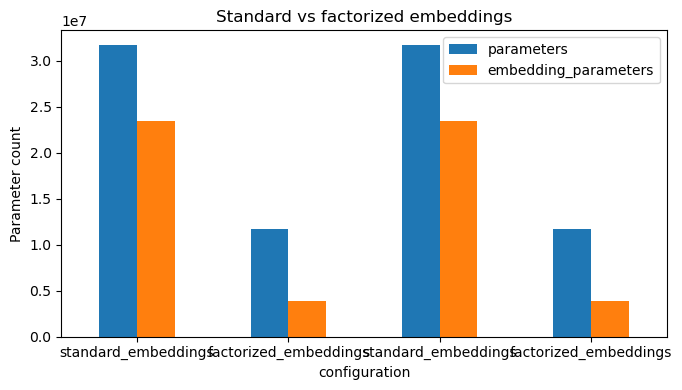

In [3]:
import matplotlib.pyplot as plt

ax = df.plot(x="configuration", y=["parameters", "embedding_parameters"],
             kind="bar", figsize=(7,4))
ax.set_ylabel("Parameter count")
ax.set_title("Standard vs factorized embeddings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
print(open("configs/factorized_embeddings/standard_embeddings.yaml").read())
print("---")
print(open("configs/factorized_embeddings/factorized_embeddings.yaml").read())

experiment_name: factorized_embeddings
configuration: standard_embeddings
model_source: from_config
architecture: albert
tokenizer_name: albert-base-v2
model_label: ALBERT-standard-embeddings
task_name: sst2
sharing_strategy: full_sharing
max_length: 128
epochs: 3
batch_size: 16
learning_rate: 2.0e-5
seed: 42
save_model: false
model_config:
  embedding_size: 768
  hidden_size: 768
  num_hidden_layers: 12
  num_attention_heads: 12
  intermediate_size: 3072

---
experiment_name: factorized_embeddings
configuration: factorized_embeddings
model_source: from_config
architecture: albert
tokenizer_name: albert-base-v2
model_label: ALBERT-factorized-embeddings
task_name: sst2
sharing_strategy: full_sharing
max_length: 128
epochs: 3
batch_size: 16
learning_rate: 2.0e-5
seed: 42
save_model: false
model_config:
  embedding_size: 128
  hidden_size: 768
  num_hidden_layers: 12
  num_attention_heads: 12
  intermediate_size: 3072



In [5]:
import unicodedate


ModuleNotFoundError: No module named 'unicodedate'

In [ ]:
import yaml, pandas as pd

def flatten(cfg):
    flat = {}
    for k, v in cfg.items():
        if isinstance(v, dict):
            for subk, subv in v.items():
                flat[subk] = subv
        else:
            flat[k] = v
    return flat

files = ["standard_embeddings.yaml", "factorized_embeddings.yaml"]
rows = {}
for f in files:
    cfg = yaml.safe_load(open("configs/factorized_embeddings/" + f))
    rows[cfg["configuration"]] = flatten(cfg)

compare = pd.DataFrame(rows)
compare

In [ ]:
diff = compare[compare.iloc[:, 0] != compare.iloc[:, 1]]
print("Fields that differ between the two configs taken from the table above:")
diff

In [ ]:
V = 30000      # vocab size (albert-base-v2)
H = 768        # hidden size
E_std = 768    # standard embedding size
E_fac = 128    # factorized embedding size

std = V * E_std                  # one big V x H table
fac = V * E_fac + E_fac * H      # two matrices: V x E + E x H
print("Title:Factorized embeddings reduce parameters ~6× — the arithmetic \n")
print(f"Standard   embedding matrix: V*H        = {V}*{E_std}            = {std:,}")
print(f"Factorized embedding matrix: V*E + E*H  = {V}*{E_fac} + {E_fac}*{H} = {fac:,}")
print(f"Reduction factor: {std/fac:.1f}x")

In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import sys
os.chdir(os.path.expanduser("~/DLNLP-ALBERT"))

SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import torch
print("In:", os.getcwd())
print("CUDA available:", torch.cuda.is_available())

In [ ]:
%run experiments/factorized_embeddings/run_factorized_embeddings.py --train

In [ ]:
%pip install "accelerate>=0.26.0"

In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import sys
os.chdir(os.path.expanduser("~/DLNLP-ALBERT"))

SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import torch
print("In:", os.getcwd())
print("CUDA available:", torch.cuda.is_available())

In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import sys
os.chdir(os.path.expanduser("~/DLNLP-ALBERT"))

SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import torch
print("In:", os.getcwd())
print("CUDA available:", torch.cuda.is_available())

In [ ]:
%run experiments/factorized_embeddings/run_factorized_embeddings.py --train

In [6]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import sys
os.chdir(os.path.expanduser("~/DLNLP-ALBERT"))

SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import torch
print("In:", os.getcwd())
print("CUDA available:", torch.cuda.is_available())

In: /home/jovyan/DLNLP-ALBERT
CUDA available: True


In [7]:
%run experiments/factorized_embeddings/run_factorized_embeddings.py --train


=== Embedding ablation config: configs/factorized_embeddings/standard_embeddings.yaml ===


/home/jovyan/DLNLP-ALBERT/src/albert_project/training.py:101: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.327300,0.540180,0.769495
2,0.283800,0.504363,0.803899
3,0.243400,0.517205,0.824541


{'experiment_name': 'factorized_embeddings', 'configuration': 'standard_embeddings', 'model_label': 'ALBERT-standard-embeddings', 'model_name': 'from_config', 'model_source': 'from_config', 'task_name': 'sst2', 'train_fraction': 1.0, 'seed': 42, 'epochs': 3.0, 'batch_size': 16, 'learning_rate': 2e-05, 'max_length': 128, 'train_examples': 67349, 'validation_examples': 872, 'parameters': 31706882, 'embedding_parameters': 23436288, 'training_time_seconds': 4503.441, 'gpu_memory_mb': 2496.9, 'notes': 'Randomly initialized controlled architecture; not a pretrained checkpoint.', 'loss': 0.517204999923706, 'accuracy': 0.8245412844036697, 'runtime': 7.1962, 'samples_per_second': 121.175, 'steps_per_second': 7.643, 'epoch': 3.0}

=== Embedding ablation config: configs/factorized_embeddings/factorized_embeddings.yaml ===


/home/jovyan/DLNLP-ALBERT/src/albert_project/training.py:101: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.422300,0.457815,0.786697
2,0.325500,0.489773,0.802752
3,0.277800,0.461503,0.813073


{'experiment_name': 'factorized_embeddings', 'configuration': 'factorized_embeddings', 'model_label': 'ALBERT-factorized-embeddings', 'model_name': 'from_config', 'model_source': 'from_config', 'task_name': 'sst2', 'train_fraction': 1.0, 'seed': 42, 'epochs': 3.0, 'batch_size': 16, 'learning_rate': 2e-05, 'max_length': 128, 'train_examples': 67349, 'validation_examples': 872, 'parameters': 11685122, 'embedding_parameters': 3906048, 'training_time_seconds': 4428.679, 'gpu_memory_mb': 2259.598, 'notes': 'Randomly initialized controlled architecture; not a pretrained checkpoint.', 'loss': 0.46150270104408264, 'accuracy': 0.8130733944954128, 'runtime': 7.1809, 'samples_per_second': 121.433, 'steps_per_second': 7.659, 'epoch': 3.0}


In [8]:
import pandas as pd
pd.read_csv("results/embedding_results.csv")

,experiment_name,configuration,model_label,model_name,model_source,task_name,parameters,embedding_parameters,notes,train_fraction,...,train_examples,validation_examples,training_time_seconds,gpu_memory_mb,loss,accuracy,runtime,samples_per_second,steps_per_second,epoch
0,factorized_embeddings,standard_embeddings,ALBERT-standard-embeddings,from_config,from_config,sst2,31706882,23436288,Randomly initialized controlled architecture; ...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,factorized_embeddings,factorized_embeddings,ALBERT-factorized-embeddings,from_config,from_config,sst2,11685122,3906048,Randomly initialized controlled architecture; ...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,factorized_embeddings,standard_embeddings,ALBERT-standard-embeddings,from_config,from_config,sst2,31706882,23436288,Randomly initialized controlled architecture; ...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,factorized_embeddings,factorized_embeddings,ALBERT-factorized-embeddings,from_config,from_config,sst2,11685122,3906048,Randomly initialized controlled architecture; ...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,factorized_embeddings,standard_embeddings,ALBERT-standard-embeddings,from_config,from_config,sst2,31706882,23436288,Randomly initialized controlled architecture; ...,1.0,...,67349.0,872.0,4503.441,2496.900,0.517205,0.824541,7.1962,121.175,7.643,3.0
5,factorized_embeddings,factorized_embeddings,ALBERT-factorized-embeddings,from_config,from_config,sst2,11685122,3906048,Randomly initialized controlled architecture; ...,1.0,...,67349.0,872.0,4428.679,2259.598,0.461503,0.813073,7.1809,121.433,7.659,3.0
